In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import json
from metpy.plots import SkewT
from metpy.units import units
from metpy.calc import dewpoint

In [2]:
today_date_str = datetime.now().strftime("%Y_%m_%d")

## Vertical profile from GFS and SST

In [3]:
def _read_gfs_point(filepath, lat, lon):
    gfs_ds = xr.open_dataset(filepath, engine="cfgrib",backend_kwargs={'filter_by_keys': {'typeOfLevel':'isobaricInhPa'}})
    point = gfs_ds.sel(latitude=lat, longitude=lon+360, method='nearest')
    print(f"GFS coordinates selected: {point.latitude.values}, {point.longitude.values}")
    
    #---GFS 2m height (opened separately)
    gfs_2m = xr.open_dataset(filepath, engine="cfgrib",backend_kwargs={'filter_by_keys':{'typeOfLevel': 'heightAboveGround','level':2}})
    point_2m = gfs_2m.sel(latitude=lat, longitude=lat, method='nearest')

    gfs_p = point.isobaricInhPa.values
    gfs_p = np.insert(gfs_p, 0, 1010)

    gfs_t = point.t.values
    gfs_t = np.insert(gfs_t, 0, point_2m.t2m.values)

    gfs_q = point.q.values
    gfs_q = np.insert(gfs_q, 0, point_2m.sh2.values)

    return gfs_t, gfs_q, gfs_p

In [4]:
def _read_sst_point(filepath, lat, lon):
    sst_ds = xr.open_dataset(filepath)
    sst_ds =  sst_ds.squeeze()
    sst_ds.sst.values = sst_ds.sst.values+273.15
    surface = sst_ds.sel(lat=lat, lon=lon+360, method='nearest')
    print(f"SST coordinates selected: {surface.lat.values}, {surface.lon.values}")
    return surface.sst.values

In [5]:
gfs_filepath = "data/gfs/gfs_20250312_06z"
sst_filepath = "data/gfs/sst_20250312"
lat, lon = 40, -67.75

gfs_t, gfs_q, gfs_p = _read_gfs_point(gfs_filepath, lat, lon)
sst = _read_sst_point(sst_filepath, lat, lon)

profile_p = np.insert(gfs_p, 0, 1020) #--- Lower pressure level added
profile_t = np.insert(gfs_t, 0, sst)
profile_q = np.insert(gfs_q, 0, gfs_q[0]) #--- Repeated because lengths must match

data = {
    "Pressure (hPa)": profile_p, 
    "Temperature (K)": profile_t,
    "Specific Humidity (kg/kg)": profile_q,
}

df = pd.DataFrame(data)
print(df)

Ignoring index file 'data/gfs/gfs_20250312_06z.5b7b6.idx' incompatible with GRIB file
skipping variable: paramId==228164 shortName='tcc'
Traceback (most recent call last):
  File "/home/jturner/miniconda3/envs/spectral_analysis/lib/python3.13/site-packages/cfgrib/dataset.py", line 725, in build_dataset_components
    dict_merge(variables, coord_vars)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jturner/miniconda3/envs/spectral_analysis/lib/python3.13/site-packages/cfgrib/dataset.py", line 641, in dict_merge
    raise DatasetBuildError(
    ...<2 lines>...
    )
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  850.,  800.,  750.,  700.,
        650.,  600.,  550.,  500.,  450.,  400.,  350.,  300.,  250.,
        200.,  150.,  100.,   70.,   50.,   40.,   30.,   20.,   15.,
         10.,    7.,    5.,    3.,    2.,    1.])) new_value=Variable(

GFS coordinates selected: 40.0, 292.25
SST coordinates selected: 40.125, 292.375
    Pressure (hPa)  Temperature (K)  Specific Humidity (kg/kg)
0           1020.0       277.259979                   0.002531
1           1010.0       266.499542                   0.002531
2           1000.0       286.368530                   0.008032
3            975.0       285.588287                   0.007861
4            950.0       284.469055                   0.007216
5            925.0       283.179016                   0.006486
6            900.0       281.804596                   0.005601
7            850.0       279.179016                   0.003720
8            800.0       276.289032                   0.001951
9            750.0       273.199066                   0.001203
10           700.0       269.744659                   0.001072
11           650.0       266.371277                   0.001000
12           600.0       262.431030                   0.000660
13           550.0       258.613953  

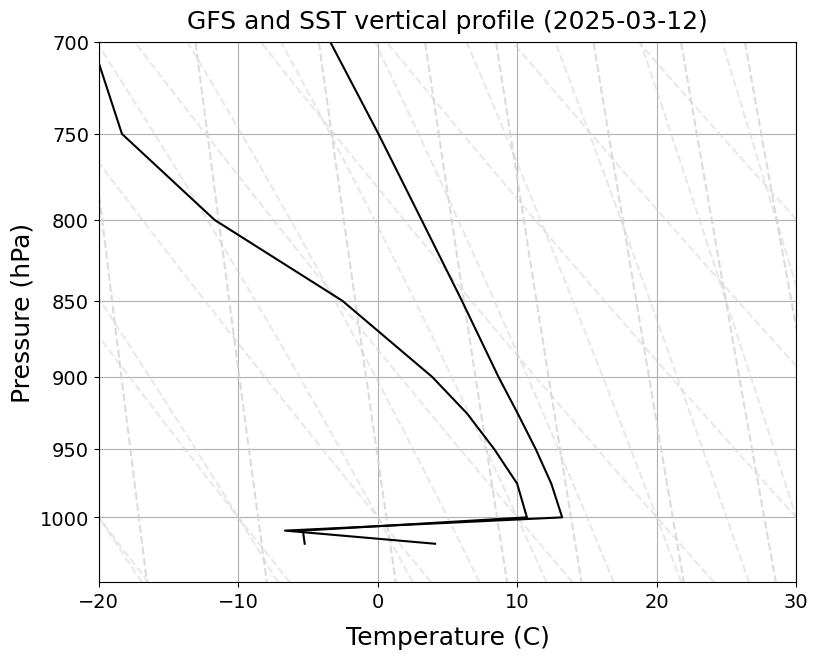

In [ ]:
pressure = df["Pressure (hPa)"].to_numpy() * units.hPa
#--- Converting from specific humidity to dewpoint
specific_humidity = df["Specific Humidity (kg/kg)"].to_numpy()
mixing_ratio = specific_humidity / (1 - specific_humidity)
vapor_pressure = (mixing_ratio * pressure) / (0.622 + mixing_ratio)
dewpoints = dewpoint(vapor_pressure)
#--- Temperature in C
temps_K = df["Temperature (K)"].to_numpy() * units.degK
temps_C = temps_K.to(units.degC)    


fig = plt.figure(figsize=(9, 9))
skew = SkewT(fig, aspect=220, rotation=0)

skew.plot(pressure, temps_C, 'k', label='Temperature')
skew.plot(pressure, dewpoints, 'k', label='Dewpoint')

skew.plot_dry_adiabats(colors='lightgray')
skew.plot_moist_adiabats(colors='lightgray')
skew.plot_mixing_lines(colors='lightgray')

skew.ax.set_ylim(1050, 700)
skew.ax.set_yticks(np.arange(1000, 700 - 1, -50))
skew.ax.set_xlim(-20, 30)
skew.ax.set_xlabel('Temperature (C)', size=18, labelpad=10)
skew.ax.set_ylabel('Pressure (hPa)', size=18)
skew.ax.tick_params(axis='both', which='major', labelsize=14)

skew.ax.set_title("GFS and SST vertical profile (2025-03-12)", size=18, pad=10)
plt.savefig(f"plots/{today_date_str}_skew_t_gfs_sst.png", dpi=300, bbox_inches='tight')
plt.show()

## Create MODTRAN JSON file

In [7]:
def _q_to_ppmv(q):
    """
    Convert specific humidity (kg/kg) to ppmv for water vapor.
    
    Parameters
    ----------
    q : float or array
        Specific humidity in kg/kg.
    
    Returns
    -------
    ppmv : float or array
        Water vapor concentration in ppmv.
    """
    eps = 0.622  # ratio of molar masses (Mv / Md)
    w = q / (1 - q)                  # mixing ratio (kg/kg dry air)
    x_v = (w / eps) / (1 + w / eps)  # mole fraction of water vapor
    ppmv = x_v * 1e6
    return ppmv

In [8]:
json_path = "data/modtran/modtran_json/2025031206_40_67-75_cloud.json"

water_vapor = _q_to_ppmv(df["Specific Humidity (kg/kg)"]).tolist()
temperature = df["Temperature (K)"].tolist()
pressure = df["Pressure (hPa)"].tolist()

n_layers = len(pressure)

modtran_dict = {
    "MODTRAN": [
        {
            "MODTRANINPUT": {
                "NAME": "flc_custom1",
                "DESCRIPTION": "",
                "CASE": 0,
                "RTOPTIONS": {
                    "MODTRN": "RT_MODTRAN",
                    "LYMOLC": False,
                    "T_BEST": False,
                    "IEMSCT": "RT_THERMAL_ONLY",
                    "IMULT": "RT_NO_MULTIPLE_SCATTER"
                },
                "ATMOSPHERE": {
                    "MODEL": "ATM_USER_PRESS_PROFILE",
                    "MDEF": 1,
                    "CO2MX": 0.0,
                    "HMODEL": "New Atm Profile",
                    "NPROF": 3,
                    "NLAYERS": n_layers,
                    "PROFILES": [
                        {
                            "TYPE": "PROF_PRESSURE",
                            "UNITS": "UNT_PMILLIBAR",
                            "PROFILE": pressure
                        },
                        {
                            "TYPE": "PROF_TEMPERATURE",
                            "UNITS": "UNT_TKELVIN",
                            "PROFILE": temperature
                        },
                        {
                            "TYPE": "PROF_H2O",
                            "UNITS": "UNT_DPPMV",
                            "PROFILE": water_vapor
                        }
                    ]
                },
                "AEROSOLS": {
                    "IHAZE": "AER_MARITIME",
                    "VIS": 0.0
                },
                "GEOMETRY": {},
                "SURFACE": {
                    "SURFTYPE": "REFL_CONSTANT",
                    "NSURF": 1,
                    "SALBFL": ""
                },
                "SPECTRAL": {
                    "V1": 650.0,
                    "V2": 3125.0,
                    "DV": 1.0,
                    "FWHM": 2.0,
                    "LBMNAM": "T",
                    "BMNAME": "p1_2013"
                },
                "FILEOPTIONS": {}
            }
        }
    ]
}

# --- write JSON file ---
with open(json_path, "w") as f:
    json.dump(modtran_dict, f, indent=2)

print(f"MODTRAN JSON saved to {json_path}")

MODTRAN JSON saved to data/modtran/modtran_json/2025031206_40_67-75_cloud.json


## WYO radiosonde

In [9]:
radiosonde_filepath = "data/radiosonde/sounding_yqi_text_2024_06_20_00z.rtf"

In [10]:
col_names = ['PRES', 'HGHT', 'TEMP', 'DWPT', 'RELH', 'MIXR', 'DRCT', 'SKNT', 'THTA', 'THTE', 'THTV']
col_widths = [7]*len(col_names)

df = pd.read_fwf(radiosonde_filepath, widths=col_widths, names=col_names, skiprows=16, skipfooter=32)